--- Dataset Preview ---
     SqFt  Bedrooms  Age          Price
0  2248.0         4   49  366167.513901
1  1931.0         4   25  351264.617601
2  2324.0         3   33  362488.666962
3  2762.0         4   38  465827.007641
4  1883.0         3    6  351112.110045

--- Missing Values Check ---
SqFt        0
Bedrooms    0
Age         0
Price       0
dtype: int64

PART A: SIMPLE LINEAR REGRESSION
Intercept: 58905.50
Coefficient (SqFt): 144.81
Mean Absolute Error (MAE): $28,839.14
Mean Squared Error (MSE): $1,121,861,209.43
R-squared (R2) Score: 0.8079


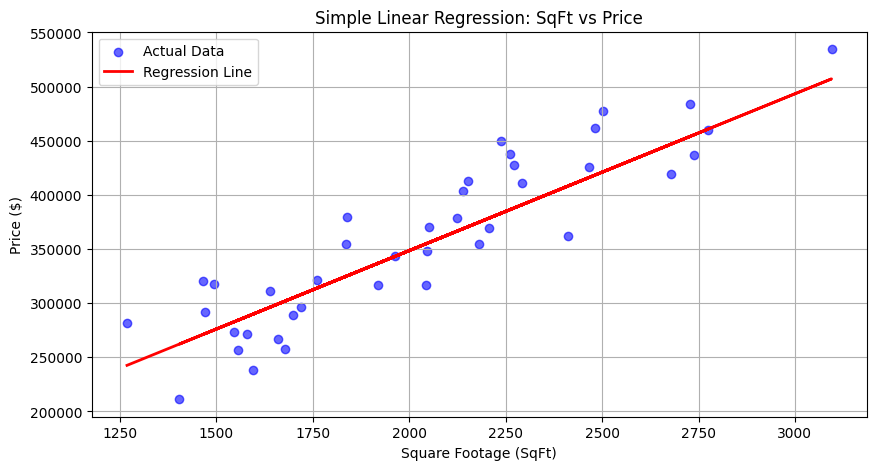


PART B: MULTIPLE LINEAR REGRESSION
Intercept: -5076.44
Coefficient (SqFt): 154.18
Coefficient (Bedrooms): 23686.63
Coefficient (Age): -1217.81
Mean Absolute Error (MAE): $12,904.10
Mean Squared Error (MSE): $261,081,411.09
R-squared (R2) Score: 0.9553


/tmp/ipykernel_2590/964771355.py:118: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'k--', lw=2, color='orange')


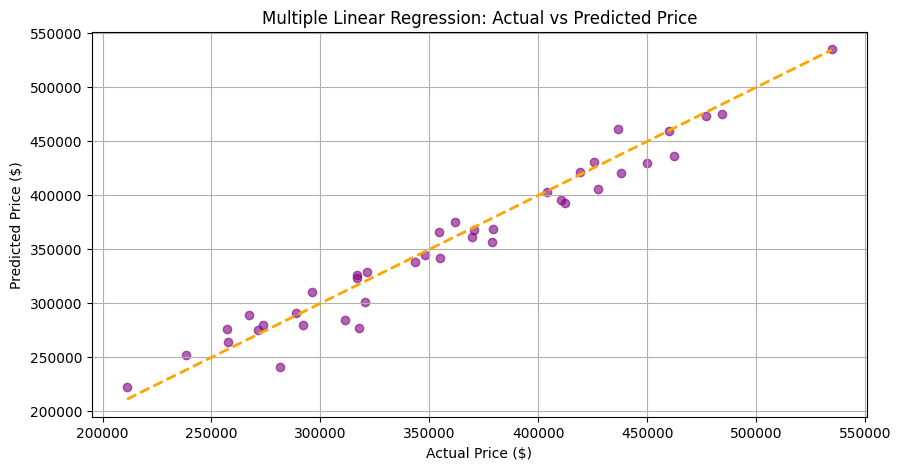

In [6]:
# ==========================================
# Task 3: Linear Regression - AI & ML Internship
# ==========================================

# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a synthetic House Price Dataset for instant execution
np.random.seed(42)
n_samples = 200

# Features
sqft = np.random.normal(2000, 500, n_samples).round()
bedrooms = np.random.choice([2, 3, 4, 5], size=n_samples, p=[0.2, 0.5, 0.2, 0.1])
age = np.random.randint(1, 50, n_samples)

# Target variable (Price in USD) with some random noise
price = (sqft * 150) + (bedrooms * 25000) - (age * 1200) + np.random.normal(0, 15000, n_samples)

# Combine into a Pandas DataFrame
df = pd.DataFrame({
    'SqFt': sqft,
    'Bedrooms': bedrooms,
    'Age': age,
    'Price': price
})

print("--- Dataset Preview ---")
print(df.head())
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# ==========================================
# PART A: Simple Linear Regression (SqFt vs Price)
# ==========================================
print("\n" + "="*40)
print("PART A: SIMPLE LINEAR REGRESSION")
print("="*40)

# Define features and target
X_simple = df[['SqFt']]
y = df['Price']

# Split data into 80% training and 20% testing
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Fit Simple Linear Regression Model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Make Predictions
y_pred_s = simple_model.predict(X_test_s)

# Evaluation Metrics
mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Coefficient (SqFt): {simple_model.coef_[0]:.2f}")
print(f"Mean Absolute Error (MAE): ${mae_s:,.2f}")
print(f"Mean Squared Error (MSE): ${mse_s:,.2f}")
print(f"R-squared (R2) Score: {r2_s:.4f}")

# Plotting the regression line
plt.figure(figsize=(10, 5))
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: SqFt vs Price')
plt.xlabel('Square Footage (SqFt)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# PART B: Multiple Linear Regression (All Features)
# ==========================================
print("\n" + "="*40)
print("PART B: MULTIPLE LINEAR REGRESSION")
print("="*40)

# Define multi-features
X_multi = df[['SqFt', 'Bedrooms', 'Age']]

# Split data (80% training, 20% testing)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Fit Multiple Linear Regression Model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# Make Predictions
y_pred_m = multi_model.predict(X_test_m)

# Evaluation Metrics
mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"Intercept: {multi_model.intercept_:.2f}")
for feature, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"Coefficient ({feature}): {coef:.2f}")

print(f"Mean Absolute Error (MAE): ${mae_m:,.2f}")
print(f"Mean Squared Error (MSE): ${mse_m:,.2f}")
print(f"R-squared (R2) Score: {r2_m:.4f}")

# Plotting Actual vs Predicted Prices
plt.figure(figsize=(10, 5))
plt.scatter(y_test_m, y_pred_m, color='purple', alpha=0.6)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'k--', lw=2, color='orange')
plt.title('Multiple Linear Regression: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True)
plt.show()
